In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st


DATA_PATH = "Data/crsp_ff3_daily_1995_2024.parquet"

df = pd.read_parquet(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

df.head()


,permno,date,ret,prc,vol,shrout,mktrf,smb,hml,rf,excess_ret
0,10026,1995-01-03,-0.010753,11.5,18872.0,9408.0,-0.0026,-0.0097,0.0094,0.0002,-0.010953
1,10026,1995-01-04,0.0,11.5,33900.0,9408.0,0.0032,-0.0029,0.0047,0.0002,-0.0002
2,10026,1995-01-05,-0.01087,11.375,6202.0,9408.0,-0.0005,0.0004,0.0005,0.0002,-0.01107
3,10026,1995-01-06,0.010989,11.5,7510.0,9408.0,0.0018,-0.0001,0.0013,0.0002,0.010789
4,10026,1995-01-09,-0.01087,11.375,4000.0,9408.0,0.0008,0.0002,0.0013,0.0002,-0.01107


In [ ]:
counts = (
    df.groupby("permno")["date"]
      .size()
      .rename("T_i")
      .sort_values(ascending=False)
      .to_frame()
)

coverage = df.groupby("permno")["date"].agg(["min", "max"])
counts = counts.join(coverage)

,T_i,min,max
permno,,,
10026,7552,1995-01-03,2024-12-31
25953,7552,1995-01-03,2024-12-31
27562,7552,1995-01-03,2024-12-31
27422,7552,1995-01-03,2024-12-31
27334,7552,1995-01-03,2024-12-31
26825,7552,1995-01-03,2024-12-31
26710,7552,1995-01-03,2024-12-31
26607,7552,1995-01-03,2024-12-31
26403,7552,1995-01-03,2024-12-31


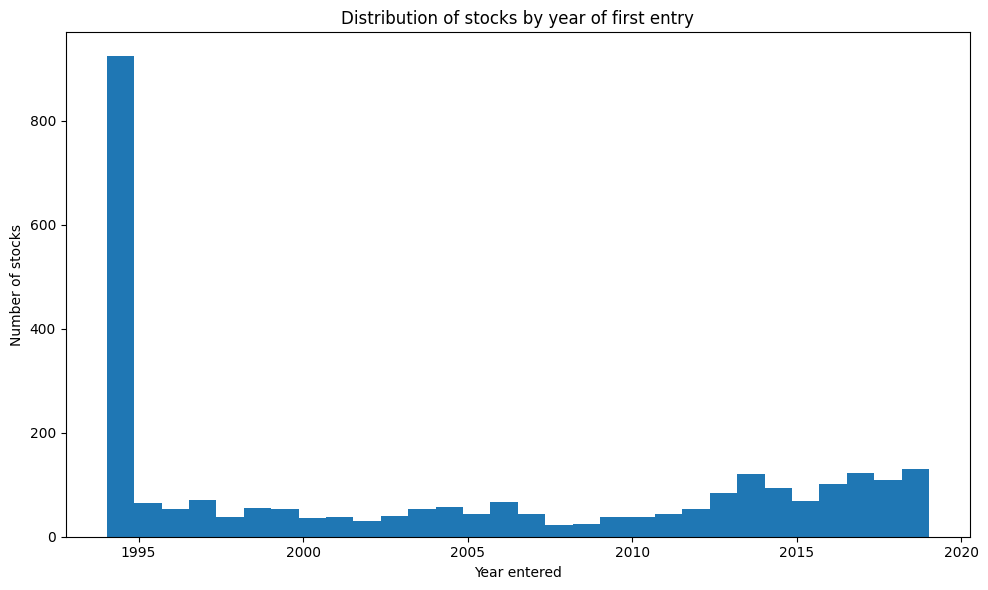

In [ ]:
Ti = counts["T_i"].to_numpy()
Years = 2024-counts["T_i"]/252

plt.figure(figsize=(10, 6))
plt.hist(Years, bins=30)
plt.xlabel("Year entered")
plt.ylabel("Number of stocks")
plt.title("Distribution of stocks by year of first entry")
plt.tight_layout()
plt.show()


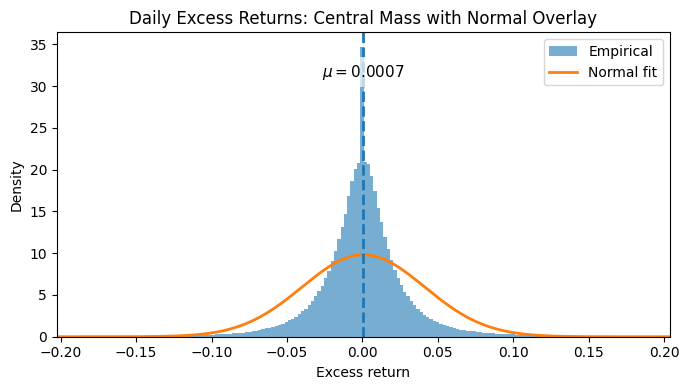

In [ ]:
r = df["excess_ret"].dropna().astype(float).values

mu = r.mean()
sigma = r.std(ddof=1)

# Trim only for visualization 
low, high = np.percentile(r, [0.5, 99.5])
r_plot = r[(r >= low) & (r <= high)]

plt.figure(figsize=(7,4))

plt.hist(r_plot, bins=120, density=True, alpha=0.6, label="Empirical")

# Normal overlay
x = np.linspace(mu - 5*sigma, mu + 5*sigma, 3000)
normal_pdf = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)
plt.plot(x, normal_pdf, linewidth=2, label="Normal fit")

# Mean line
plt.axvline(mu, linestyle="--", linewidth=2)

# Numeric label at the mean
ymax = plt.ylim()[1]
plt.text(
    mu,
    0.9 * ymax,
    f"$\\mu = {mu:.4f}$",
    ha="center",
    va="top",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
)



plt.xlim(mu - 5*sigma, mu + 5*sigma)

plt.xlabel("Excess return")
plt.ylabel("Density")
plt.title("Daily Excess Returns: Central Mass with Normal Overlay")
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/3g/bx3tqyc96sx0yxxhbmyt2fph0000gn/T/ipykernel_73689/2399735778.py:36: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/nikolauswieland/Documents/masters_thesis/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


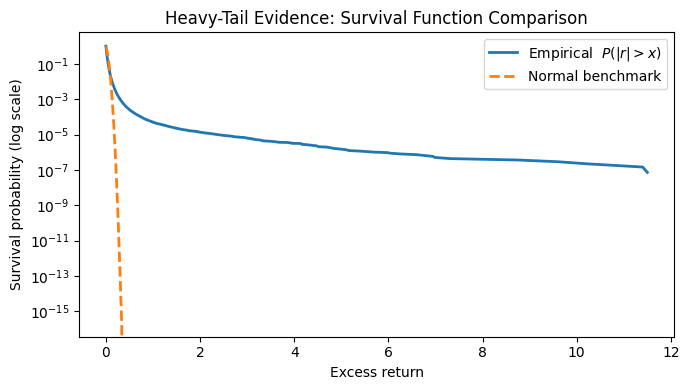

In [ ]:
# Data
r = df["excess_ret"].dropna().astype(float).values
mu = r.mean()
sigma = r.std(ddof=1)

# Absolute returns for two-sided tail
x = np.sort(np.abs(r))
n = len(x)

# Empirical survival: P(|r| > x)
emp_surv = 1.0 - np.arange(1, n+1) / n

# Normal benchmark survival
z = x / sigma
normal_surv = 2 * (1 - st.norm.cdf(z))

# Remove zero survival values (log scale safety)
mask = emp_surv > 0
x = x[mask]
emp_surv = emp_surv[mask]
normal_surv = normal_surv[mask]

# Plot
plt.figure(figsize=(7,4))
plt.plot(x, emp_surv, linewidth=2, label="Empirical  $P(|r| > x)$")
plt.plot(x, normal_surv, linewidth=2, linestyle="--",
         label="Normal benchmark")

plt.yscale("log")

plt.xlabel("Excess return")
plt.ylabel("Survival probability (log scale)")
plt.title("Heavy-Tail Evidence: Survival Function Comparison")
plt.legend()
plt.tight_layout()
plt.show()

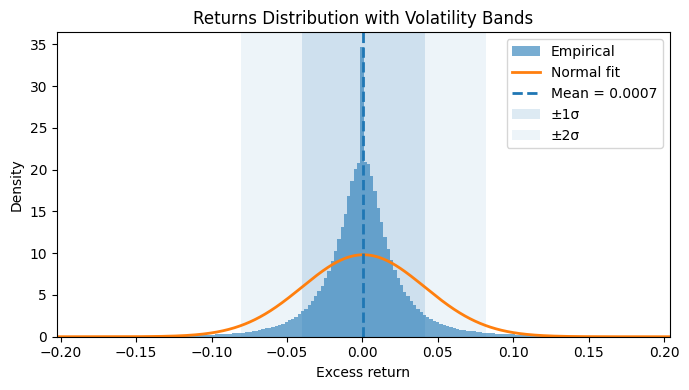

In [29]:
r = df["excess_ret"].dropna().astype(float).values
mu = r.mean()
sigma = r.std(ddof=1)

low, high = np.percentile(r, [0.5, 99.5])
r_plot = r[(r >= low) & (r <= high)]

plt.figure(figsize=(7,4))

plt.hist(r_plot, bins=120, density=True, alpha=0.6, label="Empirical")

x = np.linspace(mu - 5*sigma, mu + 5*sigma, 3000)
normal_pdf = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)
plt.plot(x, normal_pdf, linewidth=2, label="Normal fit")

# Mean
plt.axvline(mu, linestyle="--", linewidth=2, label=f"Mean = {mu:.4f}")

# Volatility bands
plt.axvspan(mu - sigma, mu + sigma, alpha=0.15, label="±1σ")
plt.axvspan(mu - 2*sigma, mu + 2*sigma, alpha=0.08, label="±2σ")

plt.xlim(mu - 5*sigma, mu + 5*sigma)

plt.xlabel("Excess return")
plt.ylabel("Density")
plt.title("Returns Distribution with Volatility Bands")
plt.legend()
plt.tight_layout()
plt.show()